# Dr.Copper — Phase 2: ARIMA baseline

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

import dr_copper as dc
from pathlib import Path

import warnings

warnings.filterwarnings("ignore")

FIGURES = Path("../outputs/figures")
DATA = Path("../data")

## 1 — Load Phase 1 outputs

In [26]:
raw_train = pd.read_parquet(DATA / "raw" / "raw_train.parquet")
raw_test = pd.read_parquet(DATA / "raw" / "raw_test.parquet")

features_train = pd.read_parquet(DATA / "processed" / "features_train.parquet")
features_test = pd.read_parquet(DATA / "processed" / "features_test.parquet")

In [27]:
price_train = raw_train["copper"].dropna()
price_test = raw_test["copper"].dropna()

log_ret_train = features_train["copper_ret1d"]
log_ret_test = features_test["copper_ret1d"]

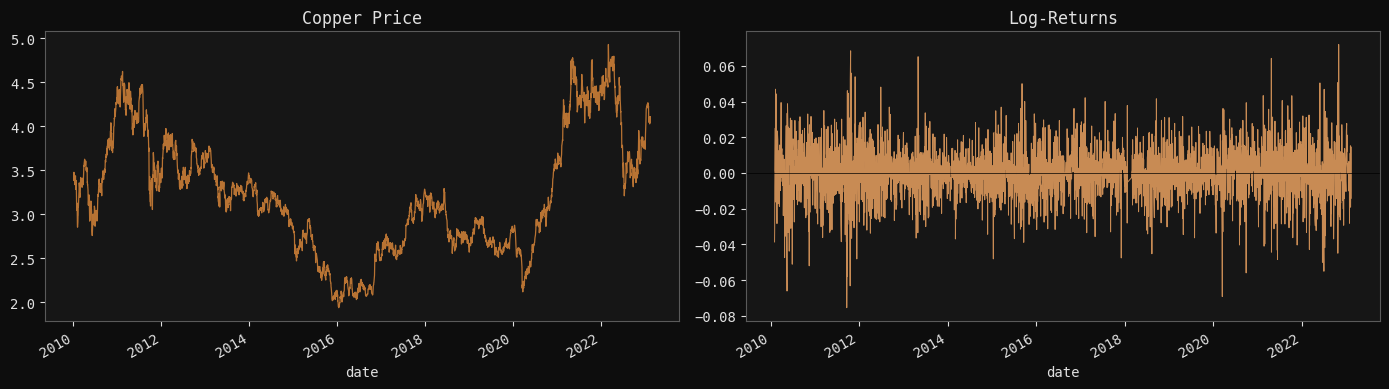

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
price_train.plot(
    ax=axes[0], title="Copper Price", color=dc.viz.COPPER_PALETTE["copper"], lw=0.9
)  # type: ignore
log_ret_train.plot(
    ax=axes[1],
    title="Log-Returns",
    color=dc.viz.COPPER_PALETTE["accent"],
    lw=0.7,
    alpha=0.85,
)  # type: ignore
axes[1].axhline(0, color="black", lw=0.5)
plt.tight_layout()

## 2 — ADF stationarity test

In [29]:
print("ADF — Prices")
dc.adf_test(price_train)
print("\nADF — Log-Returns")
dc.adf_test(log_ret_train)

ADF — Prices
ADF Statistic:  -1.8134266659435736
P-Value:  0.37381639536188915
Critical Values:
	1%: -3.43
	5%: -2.86
	10%: -2.57
Is stationary:  False

ADF — Log-Returns
ADF Statistic:  -21.46881208505766
P-Value:  0.0
Critical Values:
	1%: -3.43
	5%: -2.86
	10%: -2.57
Is stationary:  True


## 3 — Auto ARIMA daily log returns

Checked once again that prices are not stationary, we are simply going to fit the ARIMA model with pmdarima.auto_arima on log returns.

In [30]:
## auto daily log returns - adlr
model_adlr = dc.fit_arima(log_ret_train, 0)

forecasts_adlr = model_adlr.predict(len(log_ret_test))

In [31]:
recovered_train = dc.restore_prices(price_train, log_ret_train)
recovered_test = dc.restore_prices(price_test, log_ret_test)
recovered_forecast_adlr = dc.restore_prices(price_test, forecasts_adlr)

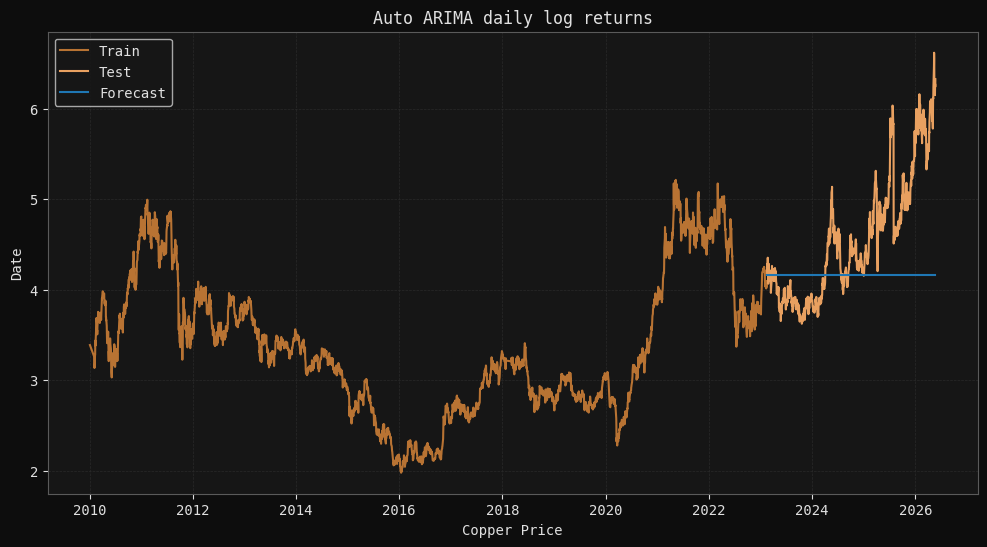

In [32]:
dc.plot_forecasts(
    recovered_train,
    recovered_test,
    recovered_forecast_adlr,
    "Auto ARIMA daily log returns",
)

The graph speaks for itself about the results.

## 4 — Monthly resample

In the previous project, we implemented TSA with monthly copper prices. So let's resample the daily data to the monthly and try to repeat the results.

In [33]:
price_train_m = price_train.resample("MS").mean()
price_test_m = price_test.resample("MS").mean()

log_ret_train_m = log_ret_train.resample("MS").sum()
log_ret_test_m = log_ret_test.resample("MS").sum()

## 5 — Auto ARIMA monthly log returns

In [34]:
## auto monthly log returns - amlr
model_amlr = dc.fit_arima(log_ret_train_m, 0)

forecasts_amlr = model_amlr.predict(len(log_ret_test_m))

In [35]:
recovered_train_m = dc.restore_prices(price_train_m, log_ret_train_m)
recovered_test_m = dc.restore_prices(price_test_m, log_ret_test_m)
recovered_forecast_amlr = dc.restore_prices(price_test_m, forecasts_amlr)

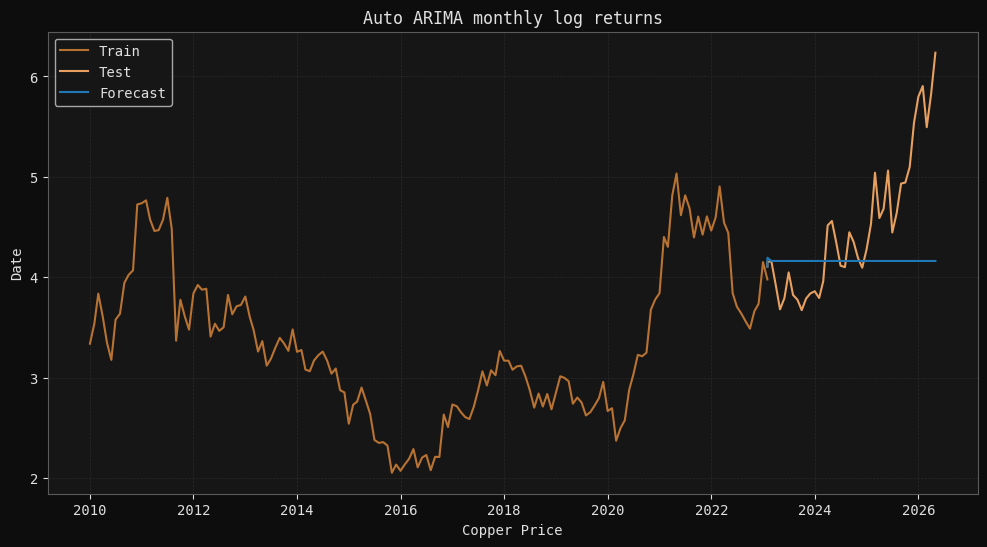

In [36]:
dc.plot_forecasts(
    recovered_train_m,
    recovered_test_m,
    recovered_forecast_amlr,
    "Auto ARIMA monthly log returns",
)

## 6 — ARIMA monthly log returns with acf/pacf lags

The Auto ARIMA model does not give us even reasonable-looking results. So we are going to manually choose the parameters for the ARIMA model with ACF/PACF graphs.

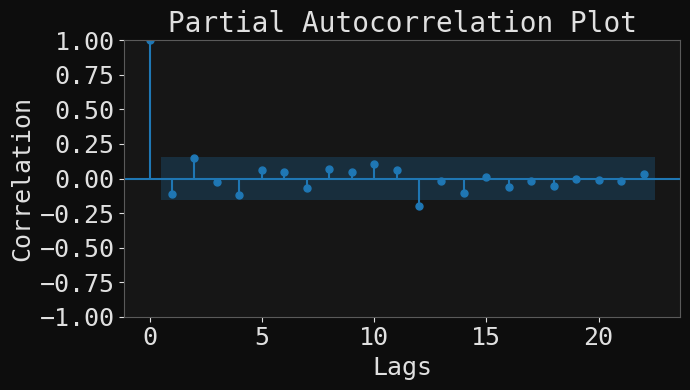

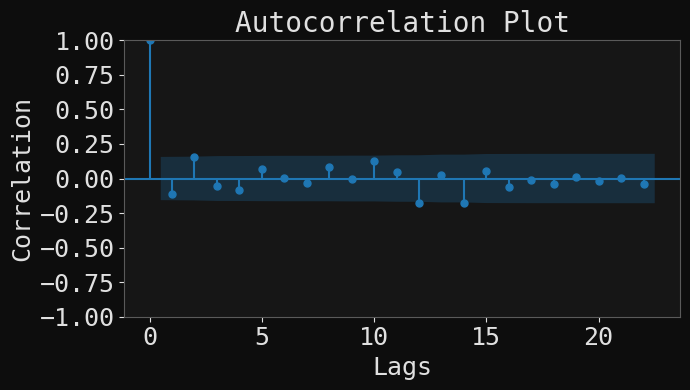

In [37]:
dc.pacf(log_ret_train_m)
dc.acf(log_ret_train_m)

In [38]:
## manual monthly log returns - mmlr
model_mmlr = ARIMA(log_ret_train_m, order=([12], 0, [2, 12, 14])).fit()
forecasts_mmlr = model_mmlr.forecast(len(log_ret_test_m))

In [39]:
recovered_forecast_mmlr = dc.restore_prices(price_test, forecasts_mmlr)

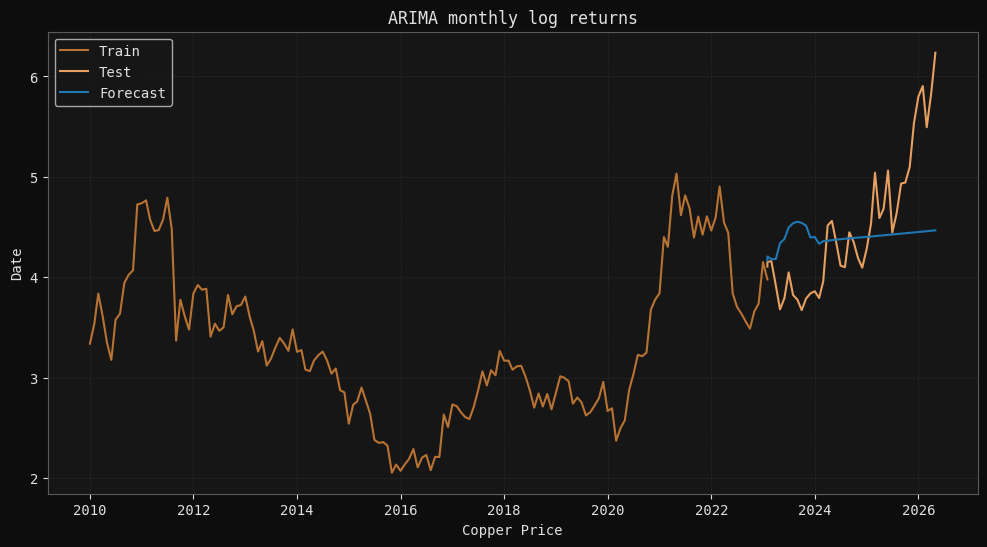

In [40]:
dc.plot_forecasts(
    recovered_train_m,
    recovered_test_m,
    recovered_forecast_mmlr,
    "ARIMA monthly log returns",
)

The results draw something and then become constant.

## 7 — ARIMA monthly raw prices with acf/pacf lags

In the previous project, we used the ARIMA model with d=1. So let's repeat that approach.

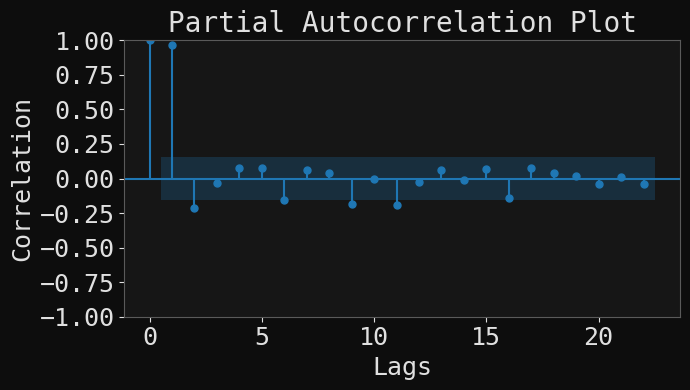

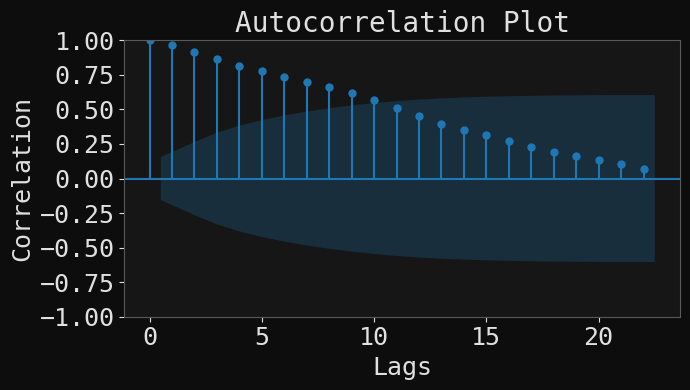

In [41]:
dc.pacf(price_train_m)
dc.acf(price_train_m)

In [42]:
## manual monthly raw prices - mmrp
model_mmrp = ARIMA(price_train_m, order=([2, 6, 9, 11, 16], 1, 10)).fit()
forecasts_mmrp = model_mmrp.forecast(len(price_test_m))

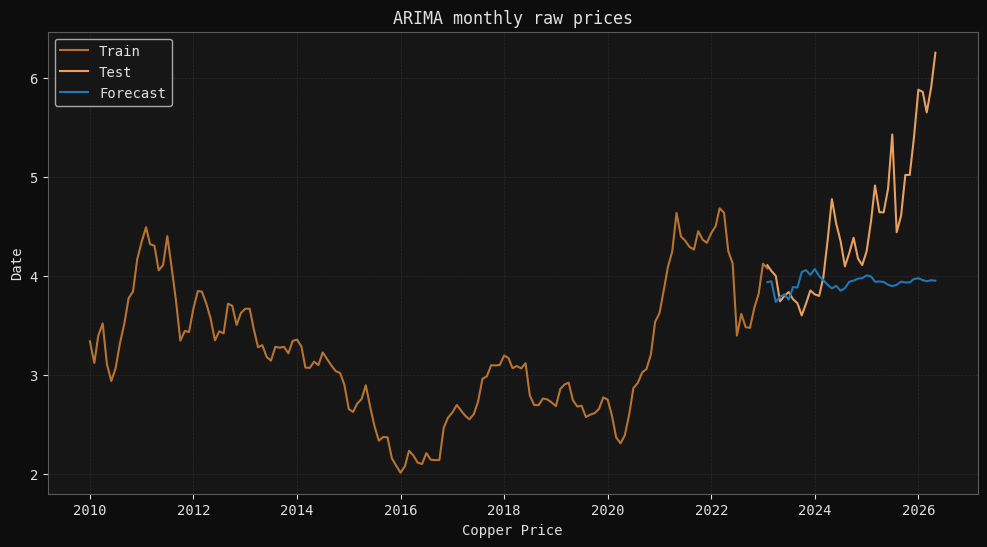

In [43]:
dc.plot_forecasts(
    price_train_m, price_test_m, forecasts_mmrp, "ARIMA monthly raw prices"
)

The results draw something at least reasonably-looking.

## 8 — ARIMA models residual diagnostics

We implemented 4 different ARIMA models. To confirm that we capture correlations between lags, we need to examine residuals.

In [44]:
dc.residuals_diagnostic(model_adlr, auto_arima=True)

ARIMA(0, 0, 0) Residual Diagnostics

Ljung-Box: ⚠ Serial correlation detected — consider higher p/q
Jarque-Bera: p=0.0000  ⚠ Non-normal residuals — GARCH captures fat tails
Engle's ARCH LM test:  ⚠ ARCH effects present → GARCH justified



In [45]:
dc.residuals_diagnostic(model_amlr, auto_arima=True)

ARIMA(0, 0, 2) Residual Diagnostics

Ljung-Box: No serial correlation in residuals
Jarque-Bera: p=0.0000  ⚠ Non-normal residuals — GARCH captures fat tails
Engle's ARCH LM test:  No strong evidence of ARCH effects.



In [46]:
dc.residuals_diagnostic(model_mmlr)

ARIMA([12], 0, [2, 12, 14]) Residual Diagnostics

Ljung-Box: No serial correlation in residuals
Jarque-Bera: p=0.0000  ⚠ Non-normal residuals — GARCH captures fat tails
Engle's ARCH LM test:  No strong evidence of ARCH effects.



In [47]:
dc.residuals_diagnostic(model_mmrp)

ARIMA([2, 6, 9, 11, 16], 1, 10) Residual Diagnostics

Ljung-Box: No serial correlation in residuals
Jarque-Bera: p=0.0000  ⚠ Non-normal residuals — GARCH captures fat tails
Engle's ARCH LM test:  No strong evidence of ARCH effects.



The results are not encouraging. 

Three models on monthly data capture correlation, but there are no ARCH effects in the retained data.

The first model, ARIMA(0, 0, 0) on daily log returns, leaves both correlation and ARCH effects, giving a naive forecast (the last value).
And we can even say that it is reasonable, because, obviously, daily market data are full of noise and dozens of different factors.

Also, everywhere we observe fat tails, which gives us a clue to use Student's t-distribution in the following GARCH model.

## 9 — Save pipeline artefacts

In [48]:
import joblib

joblib.dump(model_adlr, DATA / "processed" / "arima_adlr.joblib")
joblib.dump(model_amlr, DATA / "processed" / "arima_amlr.joblib")
joblib.dump(model_mmlr, DATA / "processed" / "arima_mmlr.joblib")
joblib.dump(model_mmrp, DATA / "processed" / "arima_mmrp.joblib")

['..\\data\\processed\\arima_mmrp.joblib']